## Modelling menggunakan arsitektur CNN 1D

### Menginstall lirary yang diperlukan

In [8]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 17.9 MB/s  0:00:17m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 43.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 45.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 48.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 65.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 39.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 36.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 43.1 MB/s  0:00:006m0:00:01
  Attempting uninstall: protobuf90m━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  4/19 [tensorboard-data-server]
    Found existing installation: protobuf 4.25.8━━━━━━━━━━━━━━  4/19 [tensorboard-data-server]
    Uninstalling protobuf-4.25.8:━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  4/19 [tensorboard-data-server]
      Successfully uninstalled protobuf-4.25.8━━━━━━━━━━━━━━━━  4/19 [tensorboard-data-serv

### Mengimport Library yang diperlukan 

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix


2025-12-14 13:38:05.712038: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-14 13:38:05.760230: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-14 13:38:08.483208: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


### Membaca File .ts

In [2]:
def read_ts_file(file_path):
    data = []
    labels = []
    is_data_section = False

    with open(file_path, "r") as f:
        for line in f:
            line = line.strip()

            # Mulai membaca setelah @data
            if line.lower() == "@data":
                is_data_section = True
                continue

            if not is_data_section:
                continue

            # Pisahkan nilai dan label
            if ":" in line:
                values, label = line.split(":")
                series = [float(x) for x in values.split(",") if x != ""]
                data.append(series)
                labels.append(label)

    return data, labels


### Load File Train dan Test 

In [3]:
train_path = "RightWhaleCalls/RightWhaleCalls_TRAIN.ts"
test_path  = "RightWhaleCalls/RightWhaleCalls_TEST.ts"

X_train, y_train = read_ts_file(train_path)
X_test, y_test = read_ts_file(test_path)

print("File loaded successfully!")


File loaded successfully!


### Konversi Data ke NumPy Array

In [4]:
X_train_np = np.array(X_train)
X_test_np  = np.array(X_test)

print("Shape sebelum reshape:", X_train_np.shape)


Shape sebelum reshape: (9324, 4000)


### Normalisasi

In [5]:
import numpy as np

def normalize_per_sample(X):
    X_norm = []
    for ts in X:
        ts = np.array(ts)
        ts = (ts - ts.mean()) / (ts.std() + 1e-8)
        X_norm.append(ts)
    return np.array(X_norm)

X_train_np = normalize_per_sample(X_train_np)
X_test_np  = normalize_per_sample(X_test_np)


### Reshape Untuk CNN 1D

In [6]:
X_train_np = X_train_np[..., np.newaxis]
X_test_np  = X_test_np[..., np.newaxis]

print("Shape sesudah reshape:", X_train_np.shape)


Shape sesudah reshape: (9324, 4000, 1)


### Encoding Label

In [7]:
encoder = LabelEncoder()

y_train_enc = encoder.fit_transform(y_train)
y_test_enc = encoder.transform(y_test)

# One-hot encoding
y_train_cat = to_categorical(y_train_enc)
y_test_cat  = to_categorical(y_test_enc)

print("Contoh label asli :", y_train[:5])
print("Contoh label encode :", y_train_enc[:5])


Contoh label asli : ['1', '1', '1', '1', '1']
Contoh label encode : [1 1 1 1 1]


### Membangun Model CNN 1D

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

model = Sequential([
    Conv1D(32, kernel_size=5, activation='relu', input_shape=(X_train_np.shape[1], 1)),
    MaxPooling1D(2),
    Dropout(0.3),

    Conv1D(64, kernel_size=5, activation='relu'),
    MaxPooling1D(2),
    Dropout(0.3),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(2, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-12-14 13:39:31.538095: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


### Menggunakan learning rate yang kecil

In [9]:
from tensorflow.keras.optimizers import Adam
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


### Early Stopping

In [10]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,   # sebelumnya 3 terlalu cepat
    restore_best_weights=True
)


### Model Checkpoint

In [11]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    "best_cnn1d_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)


In [12]:
history = model.fit(
    X_train_np,
    y_train_cat,
    epochs=12,              # batas maksimum
    batch_size=32,          # aman & stabil
    validation_split=0.2,
    callbacks=[early_stopping, checkpoint],
    verbose=1
)


Epoch 1/12


2025-12-14 13:39:47.374711: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 119344000 exceeds 10% of free system memory.


233/234 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.7113 - loss: 0.7038
Epoch 1: val_loss improved from None to 1.09536, saving model to best_cnn1d_model.keras
234/234 ━━━━━━━━━━━━━━━━━━━━ 48s 200ms/step - accuracy: 0.7500 - loss: 0.5501 - val_accuracy: 0.4209 - val_loss: 1.0954
Epoch 2/12
233/234 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.8201 - loss: 0.4256
Epoch 2: val_loss improved from 1.09536 to 0.84919, saving model to best_cnn1d_model.keras
234/234 ━━━━━━━━━━━━━━━━━━━━ 79s 187ms/step - accuracy: 0.8269 - loss: 0.4171 - val_accuracy: 0.5448 - val_loss: 0.8492
Epoch 3/12
233/234 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.8576 - loss: 0.3614
Epoch 3: val_loss improved from 0.84919 to 0.73470, saving model to best_cnn1d_model.keras
234/234 ━━━━━━━━━━━━━━━━━━━━ 47s 201ms/step - accuracy: 0.8572 - loss: 0.3608 - val_accuracy: 0.6445 - val_loss: 0.7347
Epoch 4/12
233/234 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.8728 - loss: 0.3183
Epoch 4: val_loss did not imp

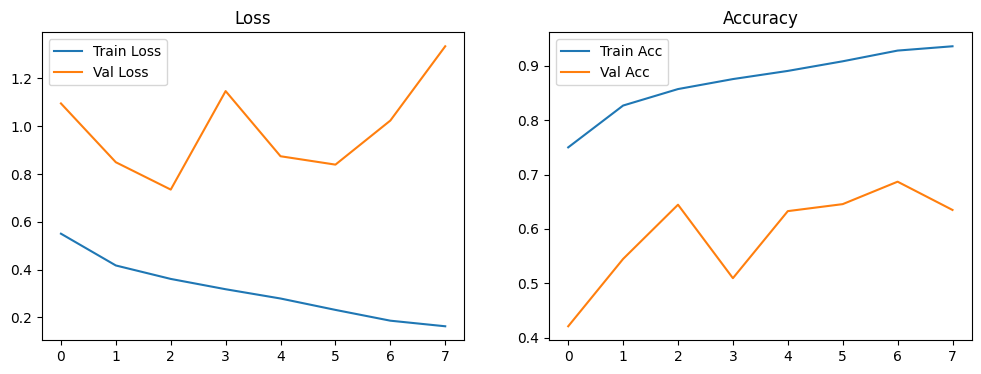

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Accuracy')

plt.show()


In [14]:
test_loss, test_acc = model.evaluate(X_test_np, y_test_cat, verbose=0)
print(f"Akurasi Data TEST: {test_acc:.4f}")


Akurasi Data TEST: 0.7829


In [15]:
y_pred = model.predict(X_test_np)
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(y_test_enc, y_pred_classes, target_names=encoder.classes_))


62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step
              precision    recall  f1-score   support

           0       0.90      0.64      0.75       981
           1       0.72      0.93      0.81       981

    accuracy                           0.78      1962
   macro avg       0.81      0.78      0.78      1962
weighted avg       0.81      0.78      0.78      1962



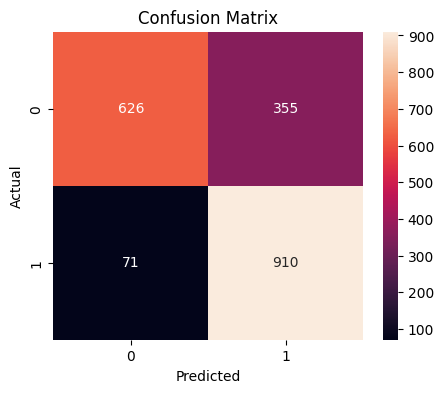

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test_enc, y_pred_classes)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
